# 🔭 ViT on CIFAR-10 — Experiment Notebook

**Architecture:** ViT (Dosovitskiy et al., 2020)  
**Dataset:** CIFAR-10 (32×32, 10 classes)  
**Features:** Live training metrics · Attention map visualization · CLS token inspection

---

In [2]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import os, sys
sys.path.append(os.path.abspath("../.."))
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from IPython.display import clear_output, display
import torchvision
import torchvision.transforms as transforms

from vit.model import build_vit
from vit.data import get_cifar10_loaders, get_tiny_imagenet_loaders

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: mps


---
## ⚙️ Experiment Configuration

Toggle the cells below to configure your experiment. No code changes needed beyond this cell.

In [6]:
# ─── CONFIGURE YOUR EXPERIMENT HERE ──────────────────────────────────────────
DATASET    = "cifar10"  # Options: "cifar10"  |  "tiny-imagenet"
ARCH       = "vit_tiny" # Options: "vit_tiny" | "vit_small" | "vit_base" | "vit_large" | "vit_huge"
BATCH_SIZE = 128
EPOCHS     = 100
LR         = 3e-4
# ─────────────────────────────────────────────────────────────────────────────

CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]

if DATASET == "cifar10":
    train_loader, val_loader = get_cifar10_loaders(BATCH_SIZE)
    num_classes, img_size = 10, 32
    class_names = CIFAR10_CLASSES
elif DATASET == "tiny-imagenet":
    train_loader, val_loader = get_tiny_imagenet_loaders(BATCH_SIZE)
    num_classes, img_size = 200, 64
    class_names = [str(i) for i in range(200)]
else:
    raise ValueError(f"Unknown dataset: {DATASET}")

print(f"📦 Dataset : {DATASET}  ({num_classes} classes, {img_size}×{img_size})")
print(f"🏗️  Arch    : {ARCH}")
print(f"📊 Batches : train={len(train_loader)} | val={len(val_loader)}")

📦 Dataset : cifar10  (10 classes, 32×32)
🏗️  Arch    : vit_tiny
📊 Batches : train=391 | val=79


---
## 🖼️ Dataset Preview

A grid of 16 random training samples with ground-truth class labels.

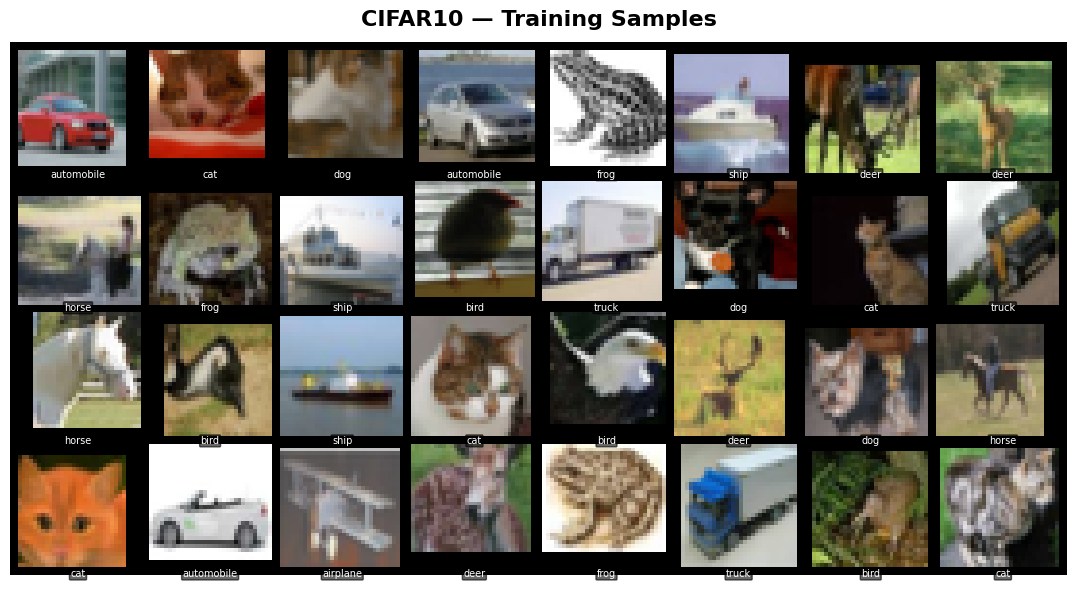

In [7]:
images, labels = next(iter(train_loader))

# Use the true dataset normalization stats to reverse normalization for display
if DATASET == "cifar10":
    mean_dn = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std_dn  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
else:
    mean_dn = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std_dn  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

imgs_show = (images[:32] * std_dn + mean_dn).clamp(0, 1)

grid = torchvision.utils.make_grid(imgs_show, nrow=8, padding=2)
npgrid = grid.permute(1, 2, 0).numpy()

fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(npgrid)
ax.set_title(f"{DATASET.upper()} — Training Samples", fontsize=16, fontweight="bold", pad=12)
ax.axis("off")

# Label strip below each image
patch_w = (grid.shape[2]) / 8
for idx in range(min(32, len(labels))):
    row, col = divmod(idx, 8)
    lbl = class_names[labels[idx].item()] if num_classes <= 10 else str(labels[idx].item())
    x_pos = col * patch_w + patch_w / 2
    y_pos = (row + 1) * (grid.shape[1] / 4) - 2
    ax.text(x_pos, y_pos, lbl, ha="center", va="top",
            fontsize=7, color="white",
            bbox=dict(boxstyle="round,pad=0.1", facecolor="black", alpha=0.6))

plt.tight_layout()
plt.show()

---
## 🏋️ Training Loop — Live Metrics

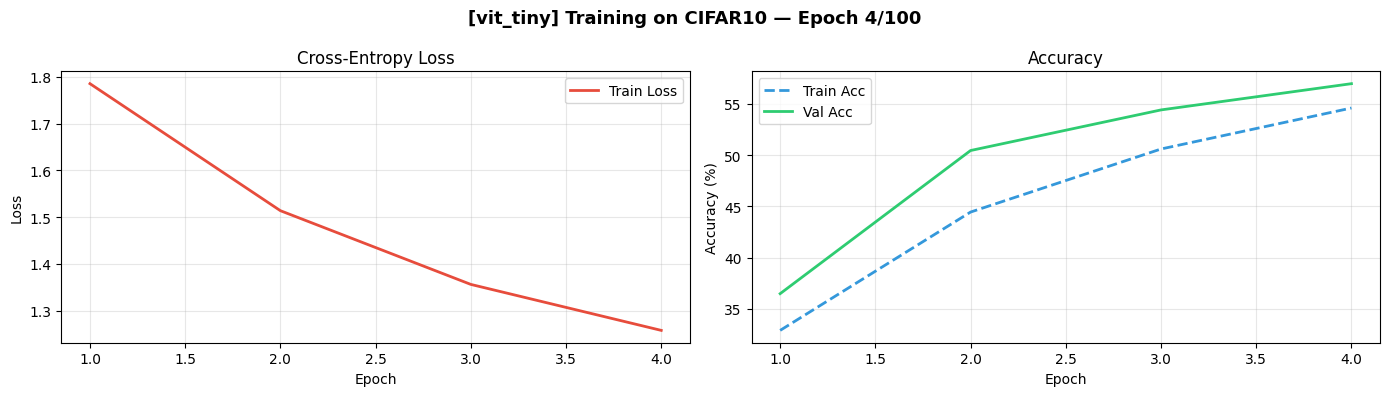

  Train E5:   0%|          | 0/391 [00:00<?, ?batch/s]

In [ ]:
from loguru import logger
from tqdm.auto import tqdm
import sys

# Route loguru to Jupyter-friendly output
logger.remove()
logger.add(sys.stdout, colorize=False,
           format="<green>{time:HH:mm:ss}</green> | <level>{level:<8}</level> | {message}")

model = build_vit(ARCH, num_classes=num_classes, img_size=img_size).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info(f"Built {ARCH} — {total_params:,} trainable parameters")

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

train_losses, val_accs, train_accs = [], [], []

epoch_bar = tqdm(range(EPOCHS), desc="Epochs", unit="epoch", position=0)

for epoch in epoch_bar:
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    batch_bar = tqdm(train_loader, desc=f"  Train E{epoch+1}", leave=False,
                     unit="batch", position=1)
    for imgs, lbls in batch_bar:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = model(imgs)
        loss = criterion(logits, lbls)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()
        _, preds = logits.max(1)
        total   += lbls.size(0)
        correct += preds.eq(lbls).sum().item()
        batch_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss  = running_loss / len(train_loader)
    train_acc = 100.0 * correct / total
    train_losses.append(avg_loss)
    train_accs.append(train_acc)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"  Val   E{epoch+1}", leave=False,
                       unit="batch", position=1)
        for imgs, lbls in val_bar:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, preds = model(imgs).max(1)
            val_total   += lbls.size(0)
            val_correct += preds.eq(lbls).sum().item()

    val_acc = 100.0 * val_correct / val_total
    val_accs.append(val_acc)
    scheduler.step()

    logger.info(
        f"Epoch {epoch+1:>3}/{EPOCHS} | "
        f"loss={avg_loss:.4f} | train={train_acc:.1f}% | val={val_acc:.1f}%"
    )
    epoch_bar.set_postfix(loss=f"{avg_loss:.4f}", val=f"{val_acc:.1f}%")

    # ── Live Plot ──────────────────────────────────────────────────────────
    clear_output(wait=True)
    epochs_done = list(range(1, epoch + 2))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"[{ARCH}] Training on {DATASET.upper()} — Epoch {epoch+1}/{EPOCHS}",
                 fontsize=13, fontweight="bold")

    ax1.plot(epochs_done, train_losses, "#e74c3c", lw=2, label="Train Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title("Cross-Entropy Loss"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_done, train_accs, "#3498db", lw=2, ls="--", label="Train Acc")
    ax2.plot(epochs_done, val_accs,   "#2ecc71", lw=2, label="Val Acc")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

logger.success(f"Training complete! Best val acc: {max(val_accs):.2f}%")

---
## 🔬 Attention Map Visualizations (CLS Token)

For each attention head in the **last encoder block**, we overlay the CLS token's attention weights
onto the original image as a heatmap. Warmer colours = regions the model attended to most.

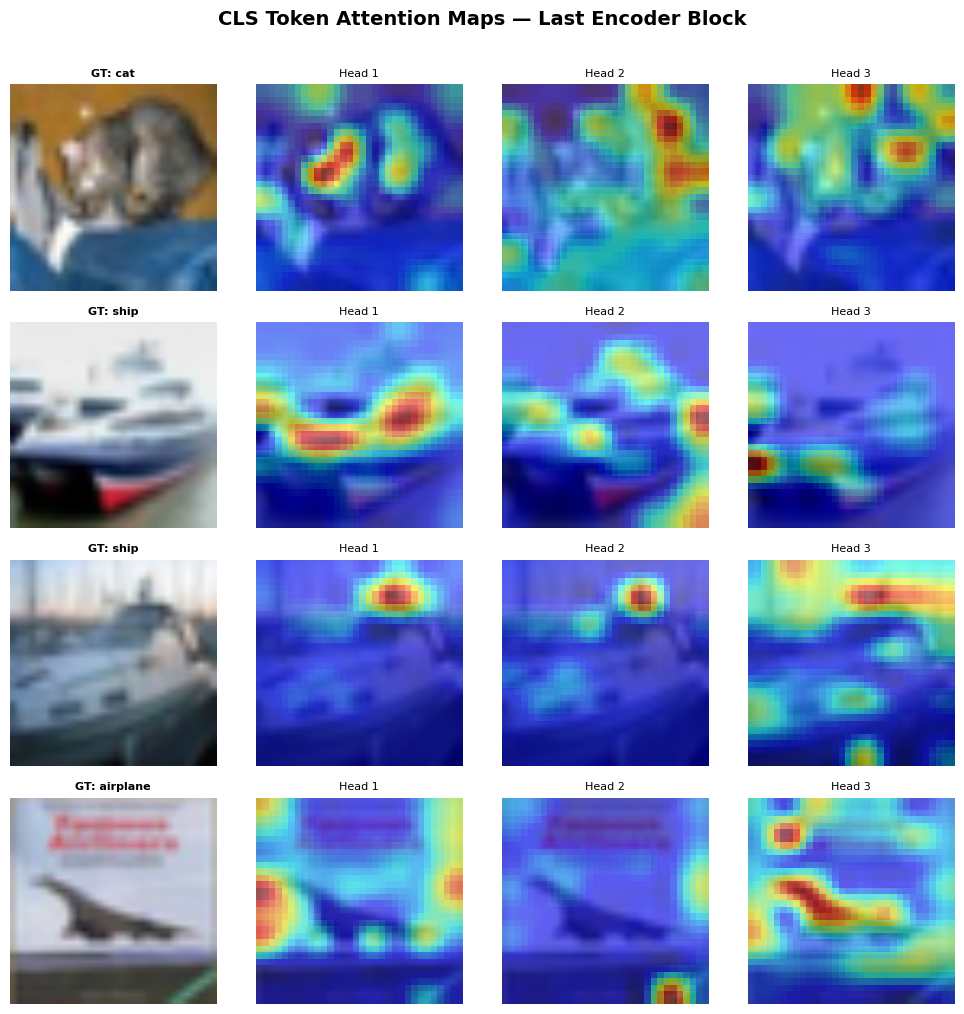

In [ ]:
model.eval()
img_tensor, gt_labels = next(iter(val_loader))
num_viz = min(4, BATCH_SIZE)                     # Visualise up to 4 images

# Dataset-aware denormalization
if DATASET == "cifar10":
    mean_dn = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std_dn  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
else:
    mean_dn = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std_dn  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig_rows = num_viz
fig_cols = model.blocks[-1].attn.n_heads + 1     # +1 for original image
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(2.5 * fig_cols, 2.5 * fig_rows))
fig.suptitle("CLS Token Attention Maps — Last Encoder Block", fontsize=14, fontweight="bold", y=1.01)

for row_idx in range(num_viz):
    single = img_tensor[row_idx:row_idx+1].to(device)

    with torch.no_grad():
        _ = model(single)
        attn_w = model.blocks[-1].attn.attention.attn_weights   # (1, H, S, S)

    cls_attn = attn_w[0, :, 0, 1:].cpu()              # (n_heads, num_patches)
    n_heads  = cls_attn.shape[0]
    gs       = int(cls_attn.shape[1] ** 0.5)

    orig = (img_tensor[row_idx] * std_dn + mean_dn).clamp(0, 1).permute(1, 2, 0).numpy()

    row_axes = axes[row_idx] if num_viz > 1 else axes

    # Original image column
    row_axes[0].imshow(orig, interpolation="bilinear")
    true_lbl = class_names[gt_labels[row_idx].item()] if num_classes <= 10 else str(gt_labels[row_idx].item())
    row_axes[0].set_title(f"GT: {true_lbl}", fontsize=8, fontweight="bold")
    row_axes[0].axis("off")

    # One column per attention head
    for h in range(n_heads):
        attn_map = cls_attn[h].reshape(1, 1, gs, gs).float()
        upscaled = F.interpolate(attn_map, size=(img_size, img_size),
                                  mode="bicubic", align_corners=False).squeeze().numpy()
        row_axes[h+1].imshow(orig, interpolation="bilinear")
        row_axes[h+1].imshow(upscaled, alpha=0.55, cmap="jet",
                              vmin=upscaled.min(), vmax=upscaled.max())
        row_axes[h+1].set_title(f"Head {h+1}", fontsize=8)
        row_axes[h+1].axis("off")

plt.tight_layout()
plt.show()